
# Temuco Heating — Main PM₂.₅ Estimation

### Pipeline prototype: Jupyter → GitHub → Streamlit

This notebook is a deliberately simplified version of the full paper analysis. It keeps only the steps required to reproduce the **main indoor PM₂.₅ estimation** and communicate the treatment-group effects in one figure.

**Reference group:** Firewood – No Insulation

**Treatment groups**
- Pellet only
- Insulation only
- Pellet + Insulation

**Main specification**

\[
\ln(PM_{2.5,it}^{indoor}) =
\beta_0 +
\beta_1 Pellet_i +
\beta_2 Insulation_i +
\beta_3 Pellet_i \times Insulation_i +
\ln(PM_{2.5,t}^{outdoor}) +
\ln(T_t^{outdoor,K}) +
HourFE + DayFE + MunicipalityFE + \varepsilon_{it}
\]

The model uses stabilized multinomial generalized propensity-score (GPS) weights, winsorized at the 1st and 99th percentiles, and household-clustered standard errors.

> **Purpose of this notebook:** test a clean, public-facing research pipeline. Diagnostics, heterogeneity analyses, robustness checks, and the indoor-temperature model from the full paper notebook are intentionally omitted.



## 1. Setup

The notebook expects `Panel_03112025.xlsx`. The easiest option is to place the Excel file in the same folder as this notebook. A few alternative paths are also checked automatically.


In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from scipy import stats as st
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from IPython.display import display

warnings.filterwarnings(
    "ignore",
    message="Unknown extension is not supported and will be removed",
    category=UserWarning,
    module=r"openpyxl.*"
)
warnings.filterwarnings(
    "ignore",
    message="Conditional Formatting extension is not supported and will be removed",
    category=UserWarning,
    module=r"openpyxl.*"
)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

SEED = 42
TRUNC_PCT = (1, 99)
MUNICIPALITY_FE = "Comuna"

SHEET_PANEL = "Panel"
SHEET_COV = "Covariates"

BASE_COVS = [
    "Anypersonolder60",
    "Chamber",
    "Disability",
    "FamilySize",
    "Perc_concrete_built",
    "Age",
    "GenderHHead1women",
    "Education",
]

INTERACTION_PAIRS = [
    ("FamilySize", "Chamber"),
    ("FamilySize", "Perc_concrete_built"),
    ("Chamber", "Perc_concrete_built"),
    ("Anypersonolder60", "Perc_concrete_built"),
]

GROUP_LABELS = {
    0: "Firewood – No Insulation",
    1: "Pellet only",
    2: "Insulation only",
    3: "Pellet + Insulation",
}

FILE_CANDIDATES = [
    Path("Panel_03112025.xlsx"),
    Path.home() / "OneDrive - Paul Scherrer Institut" / "Paper2" / "Panel_03112025.xlsx",
    Path.home() / "Documents" / "Fito" / "Temuco_2025" / "Panel_03112025.xlsx",
    Path.home() / "Documents" / "Fito" / "Temuco_2025" / "Current-review" / "Panel_03112025.xlsx",
    Path("/mnt/data/Panel_03112025.xlsx"),
]

FILE_PATH = next((p for p in FILE_CANDIDATES if p.exists()), None)

if FILE_PATH is None:
    raise FileNotFoundError(
        "Panel_03112025.xlsx was not found. "
        "Place it beside this notebook or update FILE_CANDIDATES."
    )

print("Input file:", FILE_PATH.resolve())


Input file: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\Paper2\Panel_03112025.xlsx


## 2. Load and prepare the data

In [2]:

# Read the two source sheets
df_cov = pd.read_excel(FILE_PATH, sheet_name=SHEET_COV).copy()
df_panel = pd.read_excel(FILE_PATH, sheet_name=SHEET_PANEL).copy()

# Treatment indicators
for df in (df_cov, df_panel):
    df["PELLET"] = df["T1"].astype(int)
    df["INSULATION"] = df["T2"].astype(int)

# One covariate row per household
if df_cov["ID"].duplicated().any():
    raise ValueError("Covariate sheet contains duplicated household IDs.")

# Pretreatment covariate imputation (same logic as the full analysis)
df_imputed = df_cov.copy()

age_medians = (
    df_imputed
    .groupby("Anypersonolder60", dropna=False)["Age"]
    .median()
)
for group_value, median_value in age_medians.items():
    if pd.isna(group_value):
        continue
    mask = (
        (df_imputed["Anypersonolder60"] == group_value)
        & df_imputed["Age"].isna()
    )
    df_imputed.loc[mask, "Age"] = median_value

df_imputed["Education"] = df_imputed["Education"].fillna(
    df_imputed["Education"].median()
)

missing_gender = df_imputed["GenderHHead1women"].isna()
observed_share_women = df_imputed["GenderHHead1women"].mean(skipna=True)
rng = np.random.default_rng(SEED)

if missing_gender.sum() > 0:
    df_imputed.loc[missing_gender, "GenderHHead1women"] = rng.binomial(
        1,
        observed_share_women,
        size=int(missing_gender.sum())
    )

for cov in BASE_COVS:
    if df_imputed[cov].isna().any():
        df_imputed[cov] = df_imputed[cov].fillna(df_imputed[cov].median())

# Hourly panel
df_panel["Hour"] = pd.to_numeric(df_panel["Hour"], errors="coerce")
df_panel = df_panel.dropna(subset=["Hour"]).copy()
df_panel["Hour"] = df_panel["Hour"].astype(int)

# Log-transformed environmental variables
df_panel.loc[df_panel["Pmi_cal"] <= 0, "Pmi_cal"] = np.nan
df_panel.loc[df_panel["Pmo_cal"] <= 0, "Pmo_cal"] = np.nan

df_panel["LnPMi"] = np.log(df_panel["Pmi_cal"])
df_panel["LnPMo"] = np.log(df_panel["Pmo_cal"])

df_panel["k_To"] = df_panel["To"] + 273.15
df_panel.loc[df_panel["k_To"] <= 0, "k_To"] = np.nan
df_panel["LnTo"] = np.log(df_panel["k_To"])

# Clean municipality label
df_panel[MUNICIPALITY_FE] = (
    df_panel[MUNICIPALITY_FE]
    .astype(str)
    .str.strip()
    .replace({"nan": np.nan})
)

print(f"Households: {df_cov['ID'].nunique():,}")
print(f"Hourly observations: {len(df_panel):,}")


Households: 379
Hourly observations: 18,377


## 3. Estimate stabilized multinomial GPS weights

In [3]:

def fit_multinomial_gps(X_scaled, y):
    """Unpenalized multinomial logistic regression with sklearn-version fallback."""
    try:
        model = LogisticRegression(
            solver="lbfgs",
            penalty=None,
            max_iter=4000
        )
        model.fit(X_scaled, y)
    except (TypeError, ValueError):
        model = LogisticRegression(
            solver="lbfgs",
            penalty="none",
            max_iter=4000
        )
        model.fit(X_scaled, y)
    return model


# One treatment assignment per household
id_map = (
    df_panel[["ID", "PELLET", "INSULATION"]]
    .dropna()
    .drop_duplicates(subset=["ID"])
    .copy()
)

id_map["Group"] = (
    id_map["PELLET"].astype(int).astype(str)
    + id_map["INSULATION"].astype(int).astype(str)
).map({
    "00": 0,
    "10": 1,
    "01": 2,
    "11": 3
}).astype(int)

gps = id_map.merge(
    df_imputed[["ID"] + BASE_COVS],
    on="ID",
    how="left",
    validate="one_to_one"
)

# Pretreatment interactions used in the full analysis
interaction_names = []
for var1, var2 in INTERACTION_PAIRS:
    name = f"{var1}_{var2}_interaction"
    gps[name] = gps[var1] * gps[var2]
    interaction_names.append(name)

gps_covariates = BASE_COVS + interaction_names

for cov in gps_covariates:
    if gps[cov].isna().any():
        gps[cov] = gps[cov].fillna(gps[cov].median())

X = gps[gps_covariates].astype(float)
y = gps["Group"].astype(int).to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

gps_model = fit_multinomial_gps(X_scaled, y)
probabilities = gps_model.predict_proba(X_scaled)

class_to_column = {
    int(cls): idx
    for idx, cls in enumerate(gps_model.classes_)
}

own_columns = np.array([
    class_to_column[int(group)]
    for group in y
])

p_observed = probabilities[np.arange(len(gps)), own_columns]

marginal_probability = gps["Group"].value_counts(normalize=True).to_dict()
numerator = gps["Group"].map(marginal_probability).to_numpy()

gps["p_observed"] = p_observed
gps["weight_raw"] = numerator / np.clip(p_observed, 1e-8, 1.0)

lower, upper = np.percentile(gps["weight_raw"], TRUNC_PCT)
gps["weight_gps"] = gps["weight_raw"].clip(lower, upper)
gps["Group label"] = gps["Group"].map(GROUP_LABELS)

# Merge household weights back to the hourly panel
df = df_panel.merge(
    gps[["ID", "Group", "Group label", "weight_gps"]],
    on="ID",
    how="inner",
    validate="many_to_one"
)

print("GPS model converged in:", gps_model.n_iter_)
print(f"GPS weight truncation: {lower:.3f} to {upper:.3f}")


GPS model converged in: [31]
GPS weight truncation: 0.366 to 2.854


## 4. Main GPS-weighted PM₂.₅ model

In [4]:

# Main analytical sample
required = [
    "LnPMi",
    "PELLET",
    "INSULATION",
    "LnPMo",
    "LnTo",
    "Hour",
    "DayExp",
    "ID",
    MUNICIPALITY_FE,
    "weight_gps",
]

analysis_data = df.dropna(subset=required).copy()

formula = (
    "LnPMi ~ "
    "PELLET + INSULATION + PELLET:INSULATION + "
    "LnPMo + LnTo + "
    "C(Hour) + C(DayExp) + C(Comuna)"
)

model = smf.wls(
    formula,
    data=analysis_data,
    weights=analysis_data["weight_gps"]
).fit()

model = model.get_robustcov_results(
    cov_type="cluster",
    groups=np.asarray(analysis_data["ID"]),
    use_t=False
)

print(f"Observations: {int(model.nobs):,}")
print(f"R-squared: {model.rsquared:.3f}")


Observations: 18,377
R-squared: 0.490


## 5. Treatment-group effects relative to Firewood – No Insulation

In [5]:

def exact_percent(beta):
    return 100 * (np.exp(float(beta)) - 1)

def parameter_names(model):
    if hasattr(model.params, "index"):
        return model.params.index.tolist()
    return list(model.model.exog_names)

def linear_combination(model, terms, label):
    names = parameter_names(model)
    r = np.zeros(len(names))

    for term in terms:
        r[names.index(term)] += 1.0

    beta = float(r @ np.asarray(model.params))
    covariance = np.asarray(model.cov_params())
    variance = float(r @ covariance @ r.T)
    se = float(np.sqrt(max(variance, 0.0)))

    z = beta / se if se > 0 else np.nan
    p = 2 * (1 - st.norm.cdf(abs(z))) if se > 0 else np.nan

    lo = beta - 1.96 * se
    hi = beta + 1.96 * se

    return {
        "Effect": label,
        "Coefficient": beta,
        "SE": se,
        "p-value": p,
        "Percent change": exact_percent(beta),
        "Percent CI low": exact_percent(lo),
        "Percent CI high": exact_percent(hi),
    }

specs = [
    ("Pellet only", ["PELLET"]),
    ("Insulation only", ["INSULATION"]),
    ("Pellet + Insulation", ["PELLET", "INSULATION", "PELLET:INSULATION"]),
]

results = pd.DataFrame([
    linear_combination(model, terms, label)
    for label, terms in specs
])

display(
    results[
        [
            "Effect",
            "Percent change",
            "Percent CI low",
            "Percent CI high",
            "p-value",
        ]
    ].round(3)
)


,Effect,Percent change,Percent CI low,Percent CI high,p-value
0,Pellet only,-2.3300,-7.9780,3.6650,0.4380
1,Insulation only,-2.7200,-9.1960,4.2180,0.4330
2,Pellet + Insulation,-11.8920,-17.3490,-6.0750,0.0000



## 6. Main result plot

The figure reports the estimated percentage change in indoor PM₂.₅ relative to **Firewood – No Insulation**. Error bars show 95% confidence intervals.

This is the figure we can later reproduce almost directly in a Streamlit explorer.


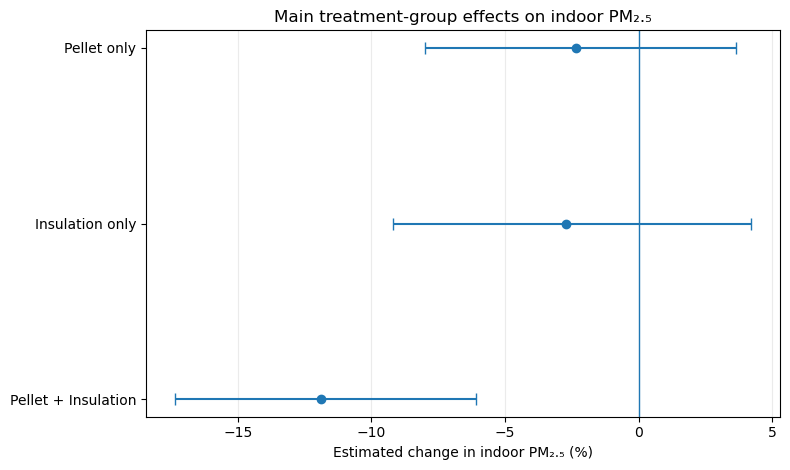

In [6]:

plot_data = results.copy()

x = plot_data["Percent change"].to_numpy()
xerr = np.vstack([
    x - plot_data["Percent CI low"].to_numpy(),
    plot_data["Percent CI high"].to_numpy() - x,
])

fig, ax = plt.subplots(figsize=(8, 4.8))

y = np.arange(len(plot_data))

ax.errorbar(
    x,
    y,
    xerr=xerr,
    fmt="o",
    capsize=4,
    linewidth=1.5
)

ax.axvline(0, linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_data["Effect"])
ax.invert_yaxis()

ax.set_xlabel("Estimated change in indoor PM₂.₅ (%)")
ax.set_title("Main treatment-group effects on indoor PM₂.₅")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()



### Interpretation

In the last executed results stored in the source paper notebook, **Pellet + Insulation** was associated with an estimated **11.9% reduction in indoor PM₂.₅** relative to Firewood – No Insulation, with a 95% CI of approximately **−17.3% to −6.1%**. The estimates for Pellet only and Insulation only were smaller and their confidence intervals crossed zero.

> The embedded plot is a preview based on those stored source-notebook estimates. Re-running this notebook with `Panel_03112025.xlsx` recalculates the model and updates the results from the data.



## 7. Why this notebook is useful for the pipeline test

This version contains only the public-facing scientific chain:

**data → GPS weights → main model → treatment effects → figure**

For the next pipeline step, this notebook can go directly into a GitHub repository. Later, the calculation logic in Sections 3–5 can be reused by a very small Streamlit application.
